# Progetto 2 – Parte 1: TimeGNN sui puzzle "matto in n"

In questa parte alleniamo la libreria TimeGNN (Wong & Damiani) sui puzzle di matto di Lichess e confrontiamo le varianti **con** e **senza** informazione temporale. La libreria non viene modificata.

TimeGNN lavora su event log (case, evento, tempo) e predice l'evento successivo. Per usarla sugli scacchi:
- **case** = un puzzle;
- **evento** = una mossa in formato UCI;
- **tempo** = istante della mossa (simulato, perché i puzzle non hanno il clock);
- **feature di ogni nodo** = la scacchiera dopo la mossa, più le mosse rimaste.

Varianti:
- **M1**: `gat_basic` senza tempo
- **M2**: `gat_basic` con tempo
- **M3**: `gat_time_decay` senza tempo
- **M4**: `gat_time_decay` con tempo

File del progetto (nella stessa cartella): questo notebook, `utils.py` (funzioni comuni) e `train.py` (training di una variante).

## Setup

Da terminale, una volta sola:
```bash
python3.12 -m venv .venv && source .venv/bin/activate
pip install torch torch_geometric "pandas<3" python-chess zstandard pyarrow scipy matplotlib requests ipykernel
pip install ./TimeGNN-main
brew install stockfish
```
- **pandas deve essere < 3.** Con pandas 3 i timestamp sono in microsecondi, la libreria li tratta come nanosecondi e i tempi diventano tutti 0.
- **Non installare l'extra `[pyg]`**: torch-scatter e torch-sparse su Mac vanno compilati e non servono.

In [15]:
import os, io, sys, json, shutil, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, chess
from utils import *

print("pandas", pd.__version__, "| torch", torch.__version__, "| MPS:", torch.backends.mps.is_available())
assert pd.__version__ < "3", "serve pandas < 3"

pandas 2.3.3 | torch 2.8.0 | MPS: True


## Configurazione

Con `SMOKE = True` si usano pochi dati e 2 epoche, per controllare che tutto funzioni. Poi si mette `False`.

In [16]:
SMOKE = False

SEED = 42
PER_N = 200 if SMOKE else 12000        # puzzle per ogni n (per n=5 ce ne sono meno, circa 3500)
TEST_PER_N = 15 if SMOKE else 300      # puzzle di test per n (gli stessi per tutti i modelli)
SEEDS = [0] if SMOKE else [0, 1, 2]

cfg = {
    "data_dir": "data_smoke" if SMOKE else "data",
    "runs_dir": "runs_smoke" if SMOKE else "runs",
    "device": "mps" if torch.backends.mps.is_available() else "cpu",
    "stockfish": shutil.which("stockfish") or "",
    "lr": 1e-3, "batch_size": 128,
    "epochs": 2 if SMOKE else 40,
    "patience": 6,
    "min_epochs": 0 if SMOKE else 10,
    "lambda_decay": 1.0,   # il default della libreria (0.01) rende il decadimento quasi nullo
}
os.makedirs(cfg["data_dir"], exist_ok=True)
os.makedirs(cfg["runs_dir"], exist_ok=True)
json.dump(cfg, open("config.json", "w"), indent=2)
cfg

{'data_dir': 'data',
 'runs_dir': 'runs',
 'device': 'mps',
 'stockfish': '/usr/local/bin/stockfish',
 'lr': 0.001,
 'batch_size': 128,
 'epochs': 40,
 'patience': 6,
 'min_epochs': 10,
 'lambda_decay': 1.0}

## 1. Download dei puzzle Lichess

Il file è di circa 300 MB, compresso in zstd.

In [17]:
import requests
RAW = "data/lichess_db_puzzle.csv.zst"
os.makedirs("data", exist_ok=True)
if not os.path.exists(RAW):
    r = requests.get("https://database.lichess.org/lichess_db_puzzle.csv.zst", stream=True)
    with open(RAW, "wb") as f:
        for chunk in r.iter_content(1 << 20):
            f.write(chunk)
print(os.path.getsize(RAW) / 1e6, "MB")

304.429328 MB


## 2. Lettura dei matti in 1–5

Leggiamo il CSV a blocchi senza decomprimerlo tutto, e teniamo solo i puzzle con tema `mateIn1` … `mateIn5`. Un matto in n deve avere 2n mosse: la prima è quella dell'avversario.

In [18]:
import zstandard

cols = ["PuzzleId", "FEN", "Moves", "Rating", "RatingDeviation", "Popularity", "Themes", "GameUrl"]
parts, read = [], 0
with open(RAW, "rb") as fh:
    text = io.TextIOWrapper(zstandard.ZstdDecompressor().stream_reader(fh), encoding="utf-8")
    for chunk in pd.read_csv(text, usecols=cols, chunksize=250_000):
        chunk["n"] = pd.to_numeric(chunk["Themes"].str.extract(r"mateIn(\d)", expand=False))
        parts.append(chunk[chunk["n"].between(1, 5)])
        read += len(chunk)
        if SMOKE and read >= 1_000_000:
            break
mate = pd.concat(parts, ignore_index=True)
mate["n"] = mate["n"].astype(int)
mate = mate[mate["Moves"].str.split().str.len() == 2 * mate["n"]]
print(len(mate), "puzzle di matto")
mate["n"].value_counts().sort_index()

1935495 puzzle di matto


n
1    898211
2    807423
3    196470
4     28698
5      4693
Name: count, dtype: int64

## 3. Pulizia, campionamento e split

- Togliamo i duplicati: stessa posizione, oppure più puzzle dalla stessa partita, che altrimenti potrebbero finire uno in train e uno in test.
- Teniamo solo puzzle con popolarità ≥ 50 e rating affidabile.
- Prendiamo lo stesso numero di puzzle per ogni n, perché altrimenti dominerebbero i matti in 1 e 2.
- Mettiamo da parte `TEST_PER_N` puzzle per n come test: sono gli stessi per tutti i modelli, baseline comprese (e poi per l'LLM). Il resto va diviso 90/10 in train e validation.

In [19]:
mate["game"] = mate["GameUrl"].str.extract(r"lichess\.org/(\w{8})", expand=False)
mate = mate.drop_duplicates("FEN").drop_duplicates("game")
mate = mate[(mate["Popularity"] >= 50) & (mate["RatingDeviation"] <= 90)]

# mescoliamo e prendiamo i primi PER_N di ogni n (o tutti, se sono meno)
puz = mate.sample(frac=1, random_state=SEED).groupby("n").head(PER_N)
test = puz.groupby("n").head(TEST_PER_N)
rest = puz.drop(test.index)
val = rest.groupby("n").sample(frac=0.1, random_state=SEED)
train = rest.drop(val.index)

pd.DataFrame({"train": train["n"].value_counts(), "val": val["n"].value_counts(),
              "test": test["n"].value_counts()}).sort_index()

,train,val,test
n,,,
1,10530,1170,300
2,10530,1170,300
3,10530,1170,300
4,10530,1170,300
5,3479,387,300


## 4. Costruzione dell'event log

Per ogni puzzle:
1. lo mettiamo in forma canonica: il risolutore gioca sempre col Bianco, e se è il Nero specchiamo scacchiera e mosse (così il modello impara ogni schema una volta sola);
2. simuliamo il tempo di ogni mossa a partire dal rating;
3. creiamo una riga per mossa.

Per il test salviamo solo i puzzle (posizione e soluzione), perché in valutazione il modello deve giocarli.

In [20]:
rng = np.random.default_rng(SEED)

def to_event_log(df):
    rows = []
    for p in df.itertuples():
        fen, moves, _ = canonical(p.FEN, p.Moves.split())
        times = [think_time(p.Rating, rng) for _ in moves]
        rows += puzzle_rows(p.PuzzleId, fen, moves, times, p.Rating, p.n)
    return pd.DataFrame(rows)

t0 = time.time()
train_df, val_df = to_event_log(train), to_event_log(val)
train_df.to_parquet(f"{cfg['data_dir']}/train.parquet")
val_df.to_parquet(f"{cfg['data_dir']}/val.parquet")

test_rows = []
for p in test.itertuples():
    fen, moves, flip = canonical(p.FEN, p.Moves.split())
    test_rows.append({"case": p.PuzzleId, "fen": fen, "moves": " ".join(moves), "n": p.n,
                      "rating": p.Rating, "flip": flip, "fen_orig": p.FEN, "moves_orig": p.Moves})
test_p = pd.DataFrame(test_rows)
test_p.to_parquet(f"{cfg['data_dir']}/test_puzzles.parquet")

print(f"{len(train_df)} righe train, {len(val_df)} righe val, {len(test_p)} puzzle test ({time.time()-t0:.0f}s)")
train_df[["case", "ply", "move", "check", "mate", "left", "t", "rating", "n"]].head(6)

245390 righe train, 27270 righe val, 1500 puzzle test (17s)


,case,ply,move,check,mate,left,t,rating,n
0,mjc2C,0,g8f8,0,0,2,0.154983,459,2
1,mjc2C,1,c6c8,1,0,1,0.088063,459,2
2,mjc2C,2,d7d8,0,0,1,0.182547,459,2
3,mjc2C,3,c8d8,1,1,0,0.195045,459,2
4,jetmr,0,g6h5,0,0,2,0.084311,949,2
5,jetmr,1,g5h5,1,0,1,0.112604,949,2


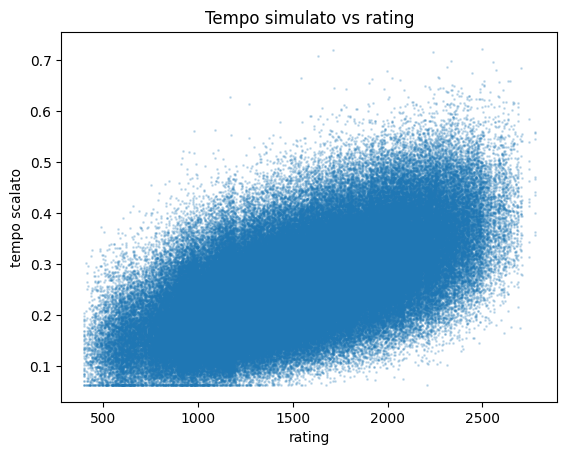

In [21]:
# il tempo simulato dipende dal rating
plt.scatter(train_df["rating"], train_df["t"], s=1, alpha=0.2)
plt.xlabel("rating"); plt.ylabel("tempo scalato"); plt.title("Tempo simulato vs rating")
plt.show()

**Attenzione per il report.** Il tempo simulato è funzione del rating (più rumore), e il rating è già una feature. Sui puzzle ci aspettiamo quindi che il tempo non aiuti. Per testarlo davvero servono tempi reali, cioè partite con il clock.

## 5. Controllo dei grafi

Proviamo `make_graphs` su pochi puzzle e verifichiamo tre cose:
- le label sono la mossa successiva (`EOS` alla fine);
- il tempo sugli archi è quello della mossa di arrivo;
- nel modello time-decay ci sono i self-loop.

I self-loop servono perché `TimeAwareGATConv` non li aggiunge da solo: senza, un nodo non vede le sue feature e dopo due livelli dipende solo dal nodo *i−2*. Su un matto in 1, che ha 2 nodi, l'output sarebbe sempre lo stesso.

In [22]:
small = train_df[train_df["case"].isin(train_df["case"].unique()[:300])]
ids = {i: m for m, i in CLASS_ID.items()}
for mode in ["gat_basic", "gat_time_decay"]:
    tr = fit_transformer(make_transformer(mode, True), small)
    one = small[small["case"] == small["case"].iloc[0]]
    g, y = make_graphs(tr, one, mode, True)[0]
    print(mode)
    print("  mosse:", one["move"].tolist())
    print("  label:", [ids[i] for i in y.view(-1).tolist()])
    print("  archi:", g.edge_index.tolist())
    print("  tempo:", (g.edge_attr.view(-1) if mode == "gat_basic" else g.time).numpy().round(3).tolist())
    print("  t mosse:", one["t"].round(3).tolist())

gat_basic
  mosse: ['g8f8', 'c6c8', 'd7d8', 'c8d8']
  label: ['c6c8', 'd7d8', 'c8d8', 'EOS']
  archi: [[0, 1, 2], [1, 2, 3]]
  tempo: [0.08799999952316284, 0.18299999833106995, 0.19499999284744263]
  t mosse: [0.155, 0.088, 0.183, 0.195]
gat_time_decay
  mosse: ['g8f8', 'c6c8', 'd7d8', 'c8d8']
  label: ['c6c8', 'd7d8', 'c8d8', 'EOS']
  archi: [[0, 1, 2, 0, 1, 2, 3], [1, 2, 3, 0, 1, 2, 3]]
  tempo: [0.08799999952316284, 0.18299999833106995, 0.19499999284744263, 0.0, 0.0, 0.0, 0.0]
  t mosse: [0.155, 0.088, 0.183, 0.195]


## 6. Baseline

Due baseline senza apprendimento, valutate sugli stessi puzzle di test:
- **random**: una mossa legale a caso;
- **greedy**: se c'è una mossa che dà matto la gioca, altrimenti preferisce uno scacco, poi una cattura. Risolve per costruzione tutti i matti in 1: serve a ricordare che il GNN riconosce schemi, non fa ricerca.

In [23]:
import random
random.seed(0)

def random_move(p, board, played):
    return random.choice([m.uci() for m in board.legal_moves])

def greedy_move(p, board, played):
    mates, checks, caps = [], [], []
    for m in board.legal_moves:
        if board.is_capture(m):
            caps.append(m.uci())
        if board.gives_check(m):
            b = board.copy(); b.push(m)
            (mates if b.is_checkmate() else checks).append(m.uci())
    return random.choice(mates or checks or caps or [m.uci() for m in board.legal_moves])

engine = chess.engine.SimpleEngine.popen_uci(cfg["stockfish"]) if cfg["stockfish"] else None
for name, fn in [("random", random_move), ("greedy", greedy_move)]:
    res = []
    for p in test_p.to_dict("records"):
        status, first_ok, played = solve(p, fn, engine)
        res.append({"system": name, "seed": 0, "case": p["case"], "n": p["n"], "status": status,
                    "solved": status == "solved", "first_ok": first_ok})
    os.makedirs(f"{cfg['runs_dir']}/{name}", exist_ok=True)
    pd.DataFrame(res).to_csv(f"{cfg['runs_dir']}/{name}/results.csv", index=False)
    print(name, pd.DataFrame(res).groupby("n")["solved"].mean().round(2).to_dict())
if engine:
    engine.quit()

random {1: 0.04, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}
greedy {1: 1.0, 2: 0.46, 3: 0.29, 4: 0.19, 5: 0.06}


## 7. Training delle 4 varianti

Ogni variante gira in un processo separato (`train.py`). Il motivo: con PyG ≥ 2.5, dopo aver creato un `GATConv` normale nello stesso processo, `TimeAwareGATConv` dà errore.

Una run già fatta viene saltata, quindi si può interrompere e ripartire. I grafi vengono salvati la prima volta e poi riusati.

Se su MPS le epoche sono lente, provare `"device": "cpu"` nella configurazione: i grafi sono piccoli e la CPU dell'M5 potrebbe essere più veloce.

In [24]:
for seed in SEEDS:
    for v in ["M1", "M2", "M3", "M4"]:
        if os.path.exists(f"{cfg['runs_dir']}/{v}_s{seed}/results.csv"):
            print(v, seed, "già fatto")
            continue
        print(f"===== {v} seed {seed} =====")
        !{sys.executable} train.py {v} {seed}

===== M1 seed 0 =====
M1: mode=gat_basic, tempo=False, device=mps, seed=0
grafi: 45599 train, 5067 val, 806 feature per nodo
epoca 1: train 3.186 acc 0.414 | val 2.109 acc 0.553 | 32s
epoca 2: train 1.806 acc 0.595 | val 1.710 acc 0.622 | 14s
epoca 3: train 1.429 acc 0.659 | val 1.556 acc 0.655 | 11s
epoca 4: train 1.218 acc 0.696 | val 1.479 acc 0.670 | 11s
epoca 5: train 1.071 acc 0.725 | val 1.441 acc 0.681 | 12s
epoca 6: train 0.959 acc 0.746 | val 1.415 acc 0.689 | 11s
epoca 7: train 0.870 acc 0.765 | val 1.413 acc 0.694 | 11s
epoca 8: train 0.801 acc 0.780 | val 1.406 acc 0.698 | 11s
epoca 9: train 0.742 acc 0.792 | val 1.409 acc 0.703 | 11s
epoca 10: train 0.688 acc 0.804 | val 1.430 acc 0.704 | 11s
epoca 11: train 0.642 acc 0.814 | val 1.446 acc 0.703 | 12s
epoca 12: train 0.602 acc 0.824 | val 1.461 acc 0.706 | 11s
epoca 13: train 0.565 acc 0.833 | val 1.471 acc 0.711 | 11s
epoca 14: train 0.536 acc 0.840 | val 1.509 acc 0.710 | 11s
early stopping
   solved  first_ok
n        

## 8. Risultati

Metriche:
- **solved**: il modello arriva al matto entro n mosse (sono accettati anche matti alternativi);
- **first_ok**: la prima mossa coincide con la soluzione.

In [25]:
import glob
res = pd.concat([pd.read_csv(f) for f in glob.glob(f"{cfg['runs_dir']}/*/results.csv")])
table = res.groupby(["system", "n"])["solved"].mean().unstack().round(3)
table

n,1,2,3,4,5
system,,,,,
M1,0.691,0.532,0.522,0.359,0.230
M2,0.704,0.553,0.527,0.353,0.227
M3,0.712,0.568,0.518,0.361,0.217
M4,0.726,0.582,0.534,0.376,0.239
greedy,1.000,0.460,0.290,0.187,0.060
random,0.040,0.000,0.000,0.000,0.000


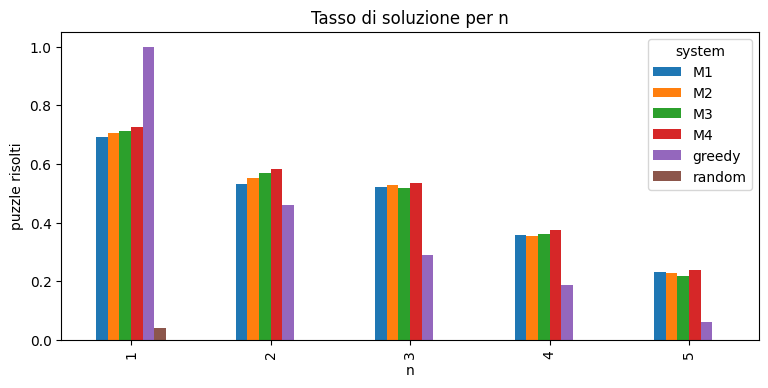

n,1,2,3,4,5
system,,,,,
M1,0.672,0.627,0.662,0.584,0.526
M2,0.688,0.631,0.664,0.563,0.518
M3,0.698,0.677,0.691,0.602,0.557
M4,0.710,0.671,0.674,0.601,0.569
greedy,0.983,0.460,0.533,0.487,0.450
random,0.040,0.033,0.027,0.033,0.023


In [26]:
table.T.plot(kind="bar", figsize=(9, 4))
plt.ylabel("puzzle risolti"); plt.xlabel("n"); plt.title("Tasso di soluzione per n")
plt.show()

res.groupby(["system", "n"])["first_ok"].mean().unstack().round(3)

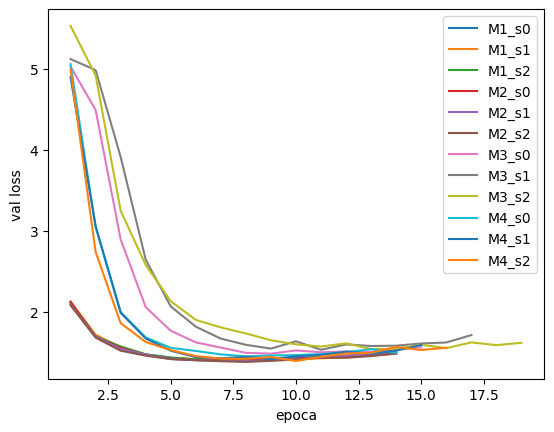

In [27]:
# curve di training
for f in sorted(glob.glob(f"{cfg['runs_dir']}/M*/history.csv")):
    h = pd.read_csv(f)
    plt.plot(h["epoch"], h["val_loss"], label=f.split("/")[-2])
plt.xlabel("epoca"); plt.ylabel("val loss"); plt.legend(); plt.show()

## 9. Il tempo aiuta? (ablation)

Confrontiamo M1 con M2 e M3 con M4 sugli stessi puzzle, con il test di McNemar. Il test guarda solo i puzzle discordanti: risolti da un modello e non dall'altro.

In [28]:
from scipy.stats import binomtest

rows = []
for a, b in [("M1", "M2"), ("M3", "M4")]:
    for seed in SEEDS:
        A = res[(res.system == a) & (res.seed == seed)].set_index("case")["solved"]
        B = res[(res.system == b) & (res.seed == seed)].set_index("case")["solved"].loc[A.index]
        only_a, only_b = int((A & ~B).sum()), int((~A & B).sum())
        p = binomtest(only_a, only_a + only_b).pvalue if only_a + only_b > 0 else 1.0
        rows.append({"confronto": f"{a} vs {b}", "seed": seed, f"solo senza tempo": only_a,
                     "solo con tempo": only_b, "diff": B.mean() - A.mean(), "p": round(p, 4)})
pd.DataFrame(rows)

,confronto,seed,solo senza tempo,solo con tempo,diff,p
0,M1 vs M2,0,118,141,0.015333,0.1715
1,M1 vs M2,1,120,129,0.006000,0.6123
2,M1 vs M2,2,148,143,-0.003333,0.8147
3,M3 vs M4,0,134,131,-0.002000,0.9022
4,M3 vs M4,1,116,172,0.037333,0.0012
5,M3 vs M4,2,127,147,0.013333,0.2510


## Note

- Senza Stockfish, se il modello devia dalla soluzione non sappiamo come risponderebbe la difesa: il puzzle viene contato come non risolto (`status = unknown`) e i risultati sono sottostimati. Per questo è meglio averlo installato.
- I matti in 5 sono pochi (circa 3500 dopo i filtri), quindi per n = 5 il training ha meno esempi.
- Nelle prove il modello time-decay rimane per qualche epoca a predire sempre `EOS` prima di iniziare a imparare. Per questo c'è `min_epochs = 10`.
- Prossimi passi:
  - tempi reali dalle partite Lichess con il clock;
  - problemi classici con n fino a 10;
  - parte 2 con l'LLM, sugli stessi `test_puzzles.parquet`.